<a href="https://colab.research.google.com/github/aabyyaann/Practical-Linear-Algebra-for-Data-Science/blob/main/Chapter15_Complex_Vectors_Hermitian_Transpose_and_Complex_Matrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 15 — Complex Vectors, Hermitian Transpose, and Complex Matrices

## Tujuan Chapter

Pada chapter ini kita memperluas konsep vektor dan matriks ke domain bilangan kompleks.

Topik yang dipelajari:

1. Complex vectors
2. Complex matrices
3. Hermitian transpose
4. Inner product kompleks
5. Norm vektor kompleks
6. Orthogonality pada ruang kompleks
7. Hermitian matrices
8. Unitary matrices
9. Eigenvalue pada matriks Hermitian
10. Hubungan dengan SVD

Konsep pada chapter ini sangat penting untuk:

- Signal Processing
- Quantum Computing
- Communications Engineering
- Fourier Analysis
- Machine Learning
- Singular Value Decomposition (SVD)

# Ringkasan Teori

Pada ruang real kita menggunakan transpose:

\[
A^T
\]

Namun pada ruang kompleks digunakan:

\[
A^H
\]

yang disebut:

## Hermitian Transpose

Hermitian transpose diperoleh dengan:

1. transpose matriks
2. mengambil konjugat kompleks setiap elemen

Secara matematis:

\[
A^H=(A^*)^T
\]

atau

\[
A^H=(A^T)^*
\]

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# 1. Membuat Vektor Kompleks

Kita mulai dengan vektor kompleks sederhana.

In [2]:
v = np.array([
    1+2j,
    3-1j,
    2+4j
])

print(v)

[1.+2.j 3.-1.j 2.+4.j]


# 2. Bagian Real dan Imajiner

In [3]:
print("Real:")
print(v.real)

print("\nImaginary:")
print(v.imag)

Real:
[1. 3. 2.]

Imaginary:
[ 2. -1.  4.]


# 3. Konjugat Kompleks

Konjugat diperoleh dengan membalik tanda bagian imajiner.

\[
a+bi \rightarrow a-bi
\]

In [4]:
v_conj = np.conjugate(v)

print(v_conj)

[1.-2.j 3.+1.j 2.-4.j]


# 4. Matriks Kompleks

In [5]:
A = np.array([
    [1+2j, 2-1j],
    [3+4j, 1+0j]
])

print(A)

[[1.+2.j 2.-1.j]
 [3.+4.j 1.+0.j]]


# 5. Transpose Biasa

Transpose hanya menukar baris dan kolom.

In [6]:
A_T = A.T

print(A_T)

[[1.+2.j 3.+4.j]
 [2.-1.j 1.+0.j]]


# 6. Hermitian Transpose

Hermitian transpose:

\[
A^H
\]

dibentuk dengan:

- transpose
- conjugate

In [7]:
A_H = A.conj().T

print(A_H)

[[1.-2.j 3.-4.j]
 [2.+1.j 1.-0.j]]


# Verifikasi Manual

In [8]:
manual = np.conjugate(A).T

print(manual)

[[1.-2.j 3.-4.j]
 [2.+1.j 1.-0.j]]


# 7. Inner Product pada Ruang Kompleks

Pada ruang real:

\[
u^Tv
\]

Pada ruang kompleks:

\[
u^Hv
\]

Inner product harus menggunakan Hermitian transpose.

In [9]:
u = np.array([
    1+1j,
    2-1j
])

v = np.array([
    2+0j,
    1+3j
])

inner = np.conjugate(u).T @ v

print(inner)

(1+5j)


# Mengapa Tidak Menggunakan Transpose Biasa?

Karena hasil inner product harus memenuhi sifat matematis tertentu, termasuk menghasilkan norm yang selalu non-negatif.

In [10]:
wrong = u.T @ v

print(wrong)

(7+7j)


# 8. Norm Vektor Kompleks

Norm kompleks:

\[
||v||
=
\sqrt{v^Hv}
\]

In [11]:
v = np.array([
    1+2j,
    3+1j
])

norm_v = np.sqrt(
    np.conjugate(v).T @ v
)

print(norm_v)

(3.872983346207417+0j)


# Verifikasi dengan NumPy

In [12]:
print(np.linalg.norm(v))

3.872983346207417


# 9. Orthogonality pada Ruang Kompleks

Dua vektor kompleks orthogonal jika:

\[
u^Hv=0
\]

In [13]:
u = np.array([
    1,
    1j
])

v = np.array([
    1,
    1j
])

test = np.conjugate(u).T @ v

print(test)

(2+0j)


# Contoh Orthogonal

In [14]:
u = np.array([
    1,
    1j
])

v = np.array([
    1,
    -1j
])

print(np.conjugate(u).T @ v)

0j


# 10. Hermitian Matrix

Matriks Hermitian memenuhi:

\[
A=A^H
\]

Ini adalah analog matriks simetris pada ruang kompleks.

In [15]:
H = np.array([
    [2, 1+2j],
    [1-2j, 3]
])

print(H)

[[2.+0.j 1.+2.j]
 [1.-2.j 3.+0.j]]


In [16]:
print(H.conj().T)

[[2.-0.j 1.+2.j]
 [1.-2.j 3.-0.j]]


In [17]:
np.allclose(
    H,
    H.conj().T
)

True

# Sifat Matriks Hermitian

Matriks Hermitian memiliki:

- seluruh eigenvalue real
- eigenvector orthogonal
- sangat penting dalam fisika dan signal processing

In [18]:
eigvals, eigvecs = np.linalg.eig(H)

print(eigvals)

[0.2087-0.j 4.7913-0.j]


# Perhatikan

Walaupun matriks mengandung bilangan kompleks, eigenvalue tetap berupa bilangan real.

# 11. Unitary Matrix

Matriks unitary adalah analog matriks orthogonal pada ruang kompleks.

Definisi:

\[
U^HU=I
\]

In [19]:
theta = np.pi/4

U = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])

print(U)

[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]


In [20]:
U_H = U.conj().T

print(U_H @ U)

[[ 1. -0.]
 [-0.  1.]]


# Verifikasi

Jika:

\[
U^HU=I
\]

maka matriks tersebut unitary.

In [21]:
np.allclose(
    U_H @ U,
    np.eye(2)
)

True

# 12. Mengapa Unitary Penting?

Unitary matrix:

- mempertahankan panjang vektor
- mempertahankan sudut
- menjaga stabilitas numerik

Sifat ini sangat penting pada:

- QR decomposition
- Fourier transform
- SVD

# 13. Hubungan dengan Eigenvalue

Untuk matriks Hermitian:

\[
A=Q\Lambda Q^H
\]

mirip dengan eigendecomposition pada ruang real.

In [22]:
Q = eigvecs

Lambda = np.diag(eigvals)

H_reconstructed = (
    Q @ Lambda @ Q.conj().T
)

print(H_reconstructed)

[[2.-0.j 1.+2.j]
 [1.-2.j 3.-0.j]]


# Verifikasi Rekonstruksi

In [23]:
np.allclose(
    H,
    H_reconstructed
)

True

# 14. Aplikasi pada Signal Processing

Representasi kompleks digunakan untuk:

- amplitudo
- fase
- frekuensi

Signal sinusoidal dapat ditulis sebagai:

\[
e^{i\omega t}
\]

menggunakan Euler Formula.

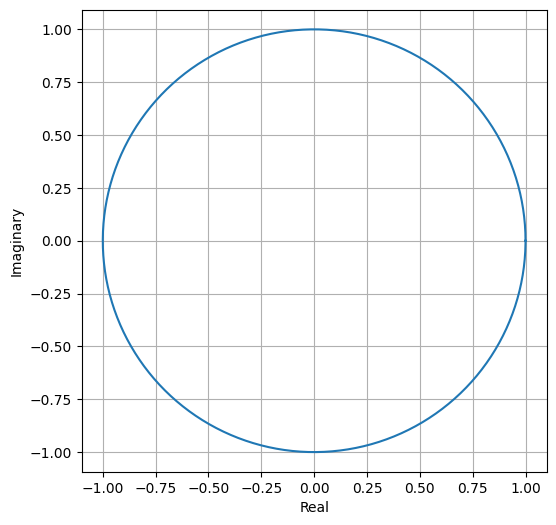

In [24]:
t = np.linspace(
    0,
    2*np.pi,
    500
)

signal = np.exp(1j*t)

plt.figure(figsize=(6,6))

plt.plot(
    signal.real,
    signal.imag
)

plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.axis('equal')
plt.grid(True)

plt.show()

# Interpretasi

Kurva yang terbentuk adalah lingkaran satuan pada bidang kompleks.

Inilah dasar dari Fourier Analysis dan transformasi sinyal.

# 15. Hubungan dengan Singular Value Decomposition (SVD)

Pada chapter berikutnya kita akan mempelajari:

\[
A=U\Sigma V^H
\]

dimana:

- U = unitary matrix
- Σ = singular values
- V = unitary matrix

Karena itu pemahaman mengenai:

- Hermitian transpose
- Hermitian matrix
- Unitary matrix

sangat penting sebelum mempelajari SVD.

# Ringkasan Chapter 15

Pada chapter ini kita mempelajari:

- Complex Vectors
- Complex Matrices
- Complex Conjugate
- Hermitian Transpose
- Complex Inner Product
- Complex Norm
- Orthogonality
- Hermitian Matrix
- Unitary Matrix
- Eigendecomposition pada ruang kompleks

Konsep-konsep ini menjadi fondasi langsung untuk Singular Value Decomposition (SVD), salah satu metode paling penting dalam linear algebra modern dan machine learning.